# SETUP

In [14]:
import sys
sys.path.append("..")

In [15]:
import torch
import torch.nn as nn
import numpy as np
import random
from torch.utils.data import DataLoader

from data_utils.scan_helpers import (
    download_scan_simple_split,
    download_scan_add_prim_split,
    load_scan_split,
    build_vocab,
    PAD,
    BOS,
    EOS,
)

from evaluation.scan_evaluation import (
    greedy_decode,
    sequence_accuracy,
    evaluate_sequence_accuracy,
    ordered_sequence_token_accuracy,   
    evaluate_ordered_token_accuracy,
    evaluate_teacher_forced_ordered_token_accuracy,
    teacher_forced_ordered_sequence_accuracy,
)

from training.train import (
    train_model,
)

from result_utils.save_results import (
    save_experiment_results,
    load_experiment_results,
)

from result_utils.plot_results import (
    exp3_plot_token_accuracy,
    exp3_plot_sequence_accuracy,
    exp3_part1_plot_token_accuracy,
    exp3_part1_plot_sequence_accuracy,
)

from data_utils.scan_dataset import ScanDataset
from data_utils.scan_dataloader import collate_scan_batch

from models.transformer import Transformer

ImportError: cannot import name 'exp3_part1_plot_token_accuracy' from 'result_utils.plot_results' (c:\Projects\Repos\GenSys\robin\experiments\..\result_utils\plot_results.py)

In [3]:
SEED_BASE = 42

In [4]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'{device} - {device_name}')

PyTorch version: 2.5.1
CUDA available: True
cuda - NVIDIA GeForce GTX 1050 Ti with Max-Q Design


In [5]:
import time
from contextlib import contextmanager

@contextmanager
def stopwatch(name: str):
    start = time.perf_counter()
    try:
        yield
    finally:
        elapsed = time.perf_counter() - start
        print(f"[{name}] Elapsed time: {elapsed:.2f} seconds")


## Load SCAN & Create Vocabulary

In [6]:
scan_dir = download_scan_add_prim_split()

train_inputs, train_outputs = load_scan_split(
    f"{scan_dir}/tasks_train_addprim_jump.txt"
)
test_inputs, test_outputs = load_scan_split(
    f"{scan_dir}/tasks_test_addprim_jump.txt"
)

print(f"Train samples: {len(train_inputs)}")
print(f"Test samples:  {len(test_inputs)}")

Train samples: 14670
Test samples:  7706


In [7]:
source_vocab = build_vocab(train_inputs)
target_vocab = build_vocab(train_outputs)

print("Source vocab size:", len(source_vocab))
print("Target vocab size:", len(target_vocab))

Source vocab size: 16
Target vocab size: 9


# Experiment PART 1 - Primitive Command JUMP & TURN_LEFT

In [8]:
# PART 1 - JUMP and TURN_LEFT 
p1_dataset_pairs = []
p1_dataset_pairs.append(("JUMP", "data/add_prim_split/tasks_train_addprim_jump.txt", "data/add_prim_split/tasks_test_addprim_jump.txt"))
p1_dataset_pairs.append(("TURN_LEFT", "data/add_prim_split/tasks_train_addprim_turn_left.txt", "data/add_prim_split/tasks_test_addprim_turn_left.txt"))

In [ ]:
p1_results = {}
p1_run_accuracies = {}
P1_NUM_RUNS = 5

print(f"Starting Part 1 Experiments, training and testing on primitive commands JUMP and TURN_LEFT")
print(f"For each dataset, training and testing will be done 5 times with different seeds, to account for variability in random initialization.")

for dataset_label, p1_train_path_base, p1_test_path_base in p1_dataset_pairs:
    with stopwatch(f"Part 1 - Command {dataset_label}"):
        print(f"Training on: {dataset_label}")

        train_inputs, train_outputs = load_scan_split(p1_train_path_base)
        test_inputs, test_outputs   = load_scan_split(p1_test_path_base)
        source_vocab = build_vocab(train_inputs)
        target_vocab = build_vocab(train_outputs)

        train_dataset = ScanDataset(
            train_inputs, train_outputs, source_vocab, target_vocab
        )
        test_dataset = ScanDataset(
            test_inputs, test_outputs, source_vocab, target_vocab
        )
        train_loader = DataLoader(
            train_dataset,
            batch_size=16,
            shuffle=True,
            collate_fn=collate_scan_batch,
        )
        test_loader = DataLoader(
            test_dataset,
            batch_size=16,
            shuffle=False,
            collate_fn=collate_scan_batch,
        )

        for run_idx in range(1, P1_NUM_RUNS + 1):
            print(f"Run {run_idx}/{P1_NUM_RUNS}")

            p1_run_seed = SEED_BASE + run_idx
            torch.manual_seed(p1_run_seed)
            random.seed(p1_run_seed)
            np.random.seed(p1_run_seed)

            model = Transformer(
                source_vocab_size=len(source_vocab),
                target_vocab_size=len(target_vocab),
                source_padding_index=PAD,
                target_padding_index=PAD,
                emb_dim=128,
                num_layers=2,
                num_heads=8,
                forward_dim=256,
                dropout=0.15,
                max_sequence_length=512,
            ).to(device)

            optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
            criterion = nn.CrossEntropyLoss(ignore_index=PAD)

            train_model(
                model=model,
                train_loader=train_loader,
                optimizer=optimizer,
                criterion=criterion,
                device=device,
                grad_clip=1.0,
                max_samples=100_000,
            )

            print(f"Evaluating token accuracy using test set with {len(test_inputs)} commands")
            final_tok_acc = evaluate_ordered_token_accuracy(model, test_loader, device)
            # print(f"Evaluating token accuracy using test set with {len(test_inputs)} commands")
            # final_tok_acc = evaluate_teacher_forced_ordered_token_accuracy(model, test_loader, device)
            print(f"Evaluating sequence accuracy using test set with {len(test_inputs)} commands")
            final_seq_acc = evaluate_sequence_accuracy(model, test_loader, device, use_oracle=False)
            
            print(f"Final (ordered) token accuracy: {final_tok_acc * 100:.2f}%")
            print(f"Final sequence accuracy: {final_seq_acc * 100:.2f}%")

            p1_run_accuracies.setdefault(dataset_label, {"seq": [], "tok": []})

            p1_run_accuracies[dataset_label]["seq"].append(final_seq_acc)
            p1_run_accuracies[dataset_label]["tok"].append(final_tok_acc)


        p1_seq_runs = np.array(p1_run_accuracies[dataset_label]["seq"], dtype=float)
        p1_tok_runs = np.array(p1_run_accuracies[dataset_label]["tok"], dtype=float)

        n = P1_NUM_RUNS

        p1_avg_seq_acc = float(p1_seq_runs.mean())
        p1_std_seq_acc = float(p1_seq_runs.std(ddof=1)) if n > 1 else 0.0
        p1_sem_seq_acc = float(p1_std_seq_acc / np.sqrt(n)) if n > 1 else 0.0

        p1_avg_tok_acc = float(p1_tok_runs.mean())
        p1_std_tok_acc = float(p1_tok_runs.std(ddof=1)) if n > 1 else 0.0
        p1_sem_tok_acc = float(p1_std_tok_acc / np.sqrt(n)) if n > 1 else 0.0

        
        print(
            f"Results for {dataset_label} | "
            f"SEQ: {p1_avg_seq_acc*100:.2f}% ± {p1_sem_seq_acc*100:.2f}% (SEM) "
            f"[std={p1_std_seq_acc*100:.2f}%] | "
            f"TOK: {p1_avg_tok_acc*100:.2f}% ± {p1_sem_tok_acc*100:.2f}% (SEM) "
            f"[std={p1_std_tok_acc*100:.2f}%]"
        )

        p1_results[dataset_label] = {
            "seq_runs": p1_seq_runs.tolist(),
            "tok_runs": p1_tok_runs.tolist(),
            "avg_seq_acc": p1_avg_seq_acc,
            "std_seq_acc": p1_std_seq_acc,
            "sem_seq_acc": p1_sem_seq_acc,
            "avg_tok_acc": p1_avg_tok_acc,
            "std_tok_acc": p1_std_tok_acc,
            "sem_tok_acc": p1_sem_tok_acc,
        }
            
        print() # New line after runs

Starting Part 1 Experiments, training and testing on primitive commands JUMP and TURN_LEFT
For each dataset, training and testing will be done 5 times with different seeds, to account for variability in random initialization.
Training on: JUMP
Run 1/5


Training samples: 100004it [02:52, 580.07it/s]                           


Training complete.
Evaluating token accuracy using test set with 7706 commands
Evaluating sequence accuracy using test set with 7706 commands
Final (ordered) token accuracy: 64.49%
Final sequence accuracy: 0.25%
Run 2/5


Training samples: 100004it [02:38, 629.78it/s]                           


Training complete.
Evaluating token accuracy using test set with 7706 commands
Evaluating sequence accuracy using test set with 7706 commands
Final (ordered) token accuracy: 65.43%
Final sequence accuracy: 0.23%
Run 3/5


...

Training complete.
Evaluating token accuracy using test set with 1208 commands
Evaluating sequence accuracy using test set with 1208 commands
Final (ordered) token accuracy: 78.86%
Final sequence accuracy: 16.23%
Run 4/5


Training samples: 100008it [02:36, 638.17it/s]                           


Training complete.
Evaluating token accuracy using test set with 1208 commands
Evaluating sequence accuracy using test set with 1208 commands
Final (ordered) token accuracy: 82.76%
Final sequence accuracy: 39.32%
Run 5/5


Training samples: 100008it [02:34, 647.24it/s]                           


Training complete.
Evaluating token accuracy using test set with 1208 commands
Evaluating sequence accuracy using test set with 1208 commands
Final (ordered) token accuracy: 81.57%
Final sequence accuracy: 28.06%
Results for TURN_LEFT | SEQ: 29.16% ± 5.62% (SEM) [std=12.57%] | TOK: 79.24% ± 1.47% (SEM) [std=3.28%]

[Part 1 - Command TURN_LEFT] Elapsed time: 1022.17 seconds


In [11]:
save_experiment_results(
    results=p1_results,
    filename="experiment_3_part1",
    experiment_nr=3,
    description="Experiment 3 Part 1: Primitive commands JUMP and TURN_LEFT",
)

Results saved to results/experiment_3\experiment_3_part1.171220252206.json


In [13]:
print(p1_results)

{'JUMP': {'seq_runs': [0.0024656112120425644, 0.0023358422008824295, 0.002076304178562159, 0.0018167661562418895, 0.0003893070334804049], 'tok_runs': [0.644854437627035, 0.6542801770338442, 0.6610358403570677, 0.6113780492536813, 0.6160992185523863], 'avg_seq_acc': 0.0018167661562418895, 'std_seq_acc': 0.0008359783757283368, 'sem_seq_acc': 0.00037386089516968426, 'avg_tok_acc': 0.6375295445648028, 'std_tok_acc': 0.022527445862578162, 'sem_tok_acc': 0.01007458006163423}, 'TURN_LEFT': {'seq_runs': [0.44370860927152317, 0.17798013245033112, 0.16225165562913907, 0.3932119205298013, 0.2806291390728477], 'tok_runs': [0.7426639156775477, 0.7875367608448756, 0.7885851238971476, 0.8276183487751168, 0.8156676914873747], 'avg_seq_acc': 0.2915562913907285, 'std_seq_acc': 0.1257207522040703, 'sem_seq_acc': 0.05622402962214154, 'avg_tok_acc': 0.7924143681364124, 'std_tok_acc': 0.03276277988766684, 'sem_tok_acc': 0.014651960592137196}}


In [16]:
import matplotlib.pyplot as plt

def exp3_part1_plot_token_accuracy(results):
    labels = list(results.keys())
    token_means = [results[label]["avg_tok_acc"] * 100 for label in labels]

    plt.figure(figsize=(6, 5))
    plt.bar(labels, token_means)
    plt.ylabel("Token Accuracy (%)")
    plt.title("Experiment 3 – Part 1: Token-Level Accuracy")
    plt.ylim(0, 100)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

def exp3_part1_plot_sequence_accuracy(results):
    labels = list(results.keys())
    seq_means = [results[label]["avg_seq_acc"] * 100 for label in labels]

    plt.figure(figsize=(6, 5))
    plt.bar(labels, seq_means)
    plt.ylabel("Sequence Accuracy (%)")
    plt.title("Experiment 3 – Part 1: Sequence-Level Accuracy")
    plt.ylim(0, 100)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()


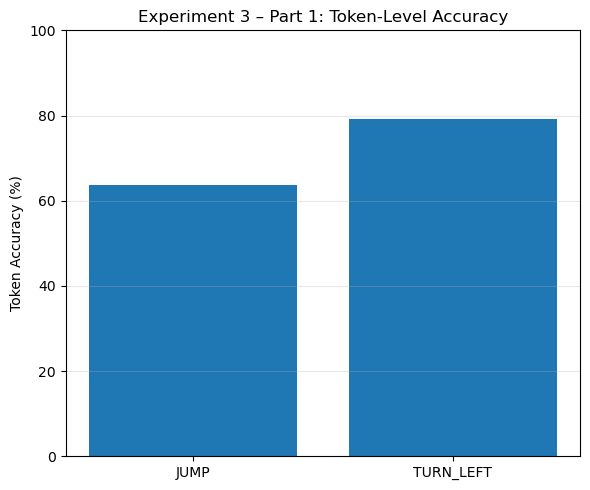

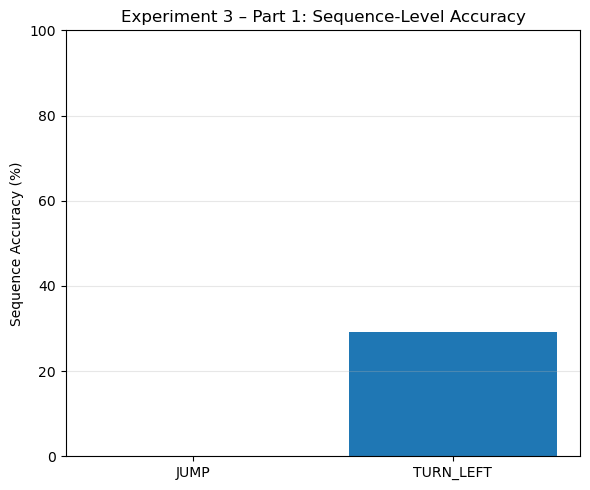

In [18]:
exp3_part1_plot_token_accuracy(p1_results)
exp3_part1_plot_sequence_accuracy(p1_results)

# Experiment PART 2 - JUMP with different number (k) composed commands

In [ ]:
# PART 2 - COMPOSED COMMANDS with varying k
p2_dataset_pairs = []
COMPOSED_COMMAND_SETTINGS = [1, 2, 4, 8, 16, 32]

for k in COMPOSED_COMMAND_SETTINGS:
        p2_base_train_path = f"data/add_prim_split/with_additional_examples/tasks_train_addprim_complex_jump_num{k}"
        p2_base_test_path  = f"data/add_prim_split/with_additional_examples/tasks_test_addprim_complex_jump_num{k}"

        p2_dataset_pairs.append((k, p2_base_train_path, p2_base_test_path))

In [ ]:
p2_results = {}
p2_run_accuracies = {}
P2_NUM_REPETITIONS = 5

print(f"Starting Part 2 Experiment, training and testing JUMP with different number (k) composed commands")
print(f"There are {len(COMPOSED_COMMAND_SETTINGS)} composed command settings with different k, there are 5 different 'repetitions' of random sampled training splits per k.")
print(f"Training/evaluation will be done on all 5 repetitions to account for variability in the sampling, per k.")



for k, p2_train_path_base, p2_test_path_base in p2_dataset_pairs:
    with stopwatch(f"Part 2 - Composed Comands k = {k}"):
        print(f"Running composed commands with k = {k}")
        for rep in range(1, P2_NUM_REPETITIONS + 1):
            print(f"Repetition {rep}/{P2_NUM_REPETITIONS}")

            p2_run_seed = SEED_BASE + rep
            torch.manual_seed(p2_run_seed)
            random.seed(p2_run_seed)
            np.random.seed(p2_run_seed)

            train_inputs, train_outputs = load_scan_split(f"{p2_train_path_base}_rep{rep}.txt")
            test_inputs, test_outputs   = load_scan_split(f"{p2_test_path_base}_rep{rep}.txt")

            # print(f"Train examples: {len(train_inputs)}")
            # print(f"Test examples: {len(test_inputs)}")

            source_vocab = build_vocab(train_inputs)
            target_vocab = build_vocab(train_outputs)

            train_dataset = ScanDataset(
                train_inputs, train_outputs, source_vocab, target_vocab
            )
            test_dataset = ScanDataset(
                test_inputs, test_outputs, source_vocab, target_vocab
            )

            train_loader = DataLoader(
                train_dataset,
                batch_size=16,
                shuffle=True,
                collate_fn=collate_scan_batch,
            )
            test_loader = DataLoader(
                test_dataset,
                batch_size=16,
                shuffle=False,
                collate_fn=collate_scan_batch,
            )

            model = Transformer(
                source_vocab_size=len(source_vocab),
                target_vocab_size=len(target_vocab),
                source_padding_index=PAD,
                target_padding_index=PAD,
                emb_dim=128,
                num_layers=2,
                num_heads=8,
                forward_dim=256,
                dropout=0.15,
                max_sequence_length=512,
            ).to(device)

            optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
            criterion = nn.CrossEntropyLoss(ignore_index=PAD)

            train_model(
                model=model,
                train_loader=train_loader,
                optimizer=optimizer,
                criterion=criterion,
                device=device,
                grad_clip=1.0,
                max_samples=100_000
            )

            print(f"Evaluating token accuracy using test set with {len(test_inputs)} commands")
            final_tok_acc = evaluate_ordered_token_accuracy(model, test_loader, device)
            # print(f"Evaluating token accuracy using test set with {len(test_inputs)} commands")
            # final_tok_acc = evaluate_teacher_forced_ordered_token_accuracy(model, test_loader, device)
            print(f"Evaluating sequence accuracy using test set with {len(test_inputs)} commands")
            final_seq_acc = evaluate_sequence_accuracy(model, test_loader, device, use_oracle=False)
            
            print(f"Final (ordered) token accuracy: {final_tok_acc * 100:.2f}%")
            print(f"Final sequence accuracy: {final_seq_acc * 100:.2f}%")

            p2_run_accuracies.setdefault(k, {"seq": [], "tok": []})

            p2_run_accuracies[k]["seq"].append(final_seq_acc)
            p2_run_accuracies[k]["tok"].append(final_tok_acc)

        p2_seq_runs = np.array(p2_run_accuracies[k]["seq"], dtype=float)
        p2_tok_runs = np.array(p2_run_accuracies[k]["tok"], dtype=float)

        n = P2_NUM_REPETITIONS

        p2_avg_seq_acc = float(p2_seq_runs.mean())
        p2_std_seq_acc = float(p2_seq_runs.std(ddof=1)) if n > 1 else 0.0
        p2_sem_seq_acc = float(p2_std_seq_acc / np.sqrt(n)) if n > 1 else 0.0

        p2_avg_tok_acc = float(p2_tok_runs.mean())
        p2_std_tok_acc = float(p2_tok_runs.std(ddof=1)) if n > 1 else 0.0
        p2_sem_tok_acc = float(p2_std_tok_acc / np.sqrt(n)) if n > 1 else 0.0

        
        print(
            f"Results for k={k} | "
            f"SEQ: {p2_avg_seq_acc*100:.2f}% ± {p2_sem_seq_acc*100:.2f}% (SEM) "
            f"[std={p2_std_seq_acc*100:.2f}%] | "
            f"TOK: {p2_avg_tok_acc*100:.2f}% ± {p2_sem_tok_acc*100:.2f}% (SEM) "
            f"[std={p2_std_tok_acc*100:.2f}%]"
        )

        p2_results[k] = {
            "seq_runs": p2_seq_runs.tolist(),
            "tok_runs": p2_tok_runs.tolist(),
            "avg_seq_acc": p2_avg_seq_acc,
            "std_seq_acc": p2_std_seq_acc,
            "sem_seq_acc": p2_sem_seq_acc,
            "avg_tok_acc": p2_avg_tok_acc,
            "std_tok_acc": p2_std_tok_acc,
            "sem_tok_acc": p2_sem_tok_acc,
        }
            
        print() # New line after runs
        
# save_experiment_results(
#     results=p2_results,
#     filename="experiment_3_part2",
#     experiment_nr=3,
#     description="Experiment 3 Part 2: Composed commands with varying k",
# )

In [ ]:
save_experiment_results(
    results=p2_results,
    filename="experiment_3_part2",
    experiment_nr=3,
    description="Experiment 3 Part 2: Composed commands with varying k",
)

In [ ]:
exp3_plot_token_accuracy(p2_results)
exp3_plot_sequence_accuracy(p2_results)